# Código 10.1 (exemplo do TECAL)

In [6]:
# Importar bibliotecas necessárias.
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score
from sklearn.calibration import CalibratedClassifierCV
import pandas as pd
import numpy as np

# Fixar uma semente aleatória para reprodutibilidade.
semente_aleatoria = 42

# Carregar o conjunto de dados TECAL e remover a a coluna id.
df = pd.read_excel('TECAL.xlsx')
df = df.drop(columns=['id'])

# Definir features (X) e variável-alvo (y).
# Converter a variável-alvo para numérico para garantir que o StratifiedKFold funcione corretamente
X = df.drop(columns=['cancel']) # features X = todas variáveis exceto 'cancel'
y = df['cancel'] # variável-alvo y = variável 'cancel'
y = y.map({'nao': 0, 'sim': 1})

# Dividir os dados em conjuntos de treino (70%) e teste (30%).
# Usar amostragem estratificada com base na variável alvo 'cancel' para manter a distribuição das classes.
treino_X, teste_X, treino_y, teste_y = train_test_split(
    X, y, test_size=0.30, random_state=semente_aleatoria, stratify=y
)

# Identificar colunas numéricas e categóricas do conjunto de features (X).
colunas_numericas = treino_X.select_dtypes(include=['int64', 'float64']).columns
colunas_categoricas = treino_X.select_dtypes(include=['category', 'object']).columns

# Criar um ColumnTransformer para aplicar as etapas de pré-processamento.
# 'num' pipeline: Padronizar features numéricas usando StandardScaler (normalização Z-score).
# 'cat' pipeline: Codificar features categóricas com OneHotEncoder (variáveis dummy).
pre_processador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), colunas_numericas), # Padronizando variáveis quantitativas (Z-scores)
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), colunas_categoricas) # Criando variáveis dummy para variáveis qualitativas, descartando a primeira categoria
    ]
)

# Aplicar o pré-processamento aos dados de treino e teste.
# O ColumnTransformer retornará um array numpy (mantemos como numpy arrays para modelagem com scikit-learn).
treino_X = pre_processador.fit_transform(treino_X)
teste_X = pre_processador.transform(teste_X)

# Definir a estratégia de validação cruzada para GridSearchCV: 4-fold estratificada.
estrategia_cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=semente_aleatoria)

# Definir os hiperparâmetros do modelo a serem ajustados para SVM (kernel linear), com base no AUROC.
grid_hiperparametros = {'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
g_SVM_linear = GridSearchCV(SVC(kernel='linear', probability=True, random_state=semente_aleatoria),
                                  grid_hiperparametros,
                                  cv=estrategia_cv,
                                  scoring='roc_auc',
                                  verbose=False)

# Definir os hiperparâmetros do modelo a serem ajustados para SVM (kernel radial), com base no AUROC
grid_hiperparametros = {'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000], 'gamma': ['scale', 'auto']}
g_SVM_radial = GridSearchCV(SVC(kernel='rbf', probability=True, random_state=semente_aleatoria),
                                  grid_hiperparametros,
                                  cv=estrategia_cv,
                                  scoring='roc_auc',
                                  verbose=False)

# Definir os hiperparâmetros do modelo a serem ajustados para SVM (kernel polinomial), com base no AUROC.
grid_hiperparametros = {'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000], 'degree': [2, 3], 'gamma': ['scale', 'auto']}
g_SVM_polinomial = GridSearchCV(SVC(kernel='poly', probability=True, random_state=semente_aleatoria),
                                  grid_hiperparametros,
                                  cv=estrategia_cv,
                                  scoring='roc_auc',
                                  verbose=False)

# Definir os hiperparâmetros do modelo a serem ajustados para KNN, com base no AUROC.
# Primeiramente, envolver o modelo KNN com CalibratedClassifierCV para Platt Scaling.
knn_calibrado = CalibratedClassifierCV(KNeighborsClassifier(), method='sigmoid', cv=estrategia_cv)
grid_hiperparametros = {'estimator__n_neighbors': [15, 35, 55, 75, 95]}
g_kNN = GridSearchCV(knn_calibrado,
                               grid_hiperparametros,
                               cv=estrategia_cv,
                               scoring='roc_auc',
                               verbose=False)

# Iterar sobre os modelos e apresentar os resultados diretamente
for nome_modelo, g in [
    ("SVM Linear", g_SVM_linear),
    ("SVM Radial", g_SVM_radial),
    ("SVM Polinomial", g_SVM_polinomial),
    ("KNN", g_kNN)
]:
    # Imprimir o nome do modelo para cada modelo
    print(f"\n*** {nome_modelo} ***")

    # Ajustar usando os dados de treino pré-processados, usando os melhores hiperparâmetros.
    g.fit(treino_X, treino_y)
    print(f"  Melhores hiperparâmetros: {g.best_params_}")

    # Obter probabilidades calibradas com escala Platt e calcular AUROC.
    probabilidades = g.best_estimator_.predict_proba(teste_X)
    auc_roc = roc_auc_score(teste_y, probabilidades[:, 1])
    print(f"  AUROC com uso da amostra de teste: {auc_roc:.3f}")

    # Previsão com corte 0.5
    previsao_corte = (probabilidades[:, 1] >= 0.5).astype(int)

    # Obter Matriz de Confusão e Acurácia (corte = 0.5)
    matriz_confusao = confusion_matrix(teste_y, previsao_corte)
    acuracia = accuracy_score(teste_y, previsao_corte)

    # Imprimir Matriz de Confusão e a Acurácia (corte = 0,5)
    print(f"  Matriz de Confusão (corte = {0.5}):")
    print("              Previsto") 
    print("              nao sim ") 
    print(f"     Real nao {matriz_confusao[0][0]:>3} {matriz_confusao[0][1]:>3}") 
    print(f"          sim {matriz_confusao[1][0]:>3} {matriz_confusao[1][1]:>3}") 
    print(f"  Acurácia (corte = {0.5}): {acuracia:.3f}")


*** SVM Linear ***
  Melhores hiperparâmetros: {'C': 1}
  AUROC com uso da amostra de teste: 0.848
  Matriz de Confusão (corte = 0.5):
              Previsto
              nao sim 
     Real nao 423  34
          sim  75  68
  Acurácia (corte = 0.5): 0.818

*** SVM Radial ***
  Melhores hiperparâmetros: {'C': 0.001, 'gamma': 'auto'}
  AUROC com uso da amostra de teste: 0.855
  Matriz de Confusão (corte = 0.5):
              Previsto
              nao sim 
     Real nao 420  37
          sim  68  75
  Acurácia (corte = 0.5): 0.825

*** SVM Polinomial ***
  Melhores hiperparâmetros: {'C': 1, 'degree': 2, 'gamma': 'auto'}
  AUROC com uso da amostra de teste: 0.820
  Matriz de Confusão (corte = 0.5):
              Previsto
              nao sim 
     Real nao 432  25
          sim  91  52
  Acurácia (corte = 0.5): 0.807

*** KNN ***
  Melhores hiperparâmetros: {'estimator__n_neighbors': 75}
  AUROC com uso da amostra de teste: 0.829
  Matriz de Confusão (corte = 0.5):
              Previs

# Código 10.2 (exemplo do MNIST)

Quantidade de imagens amostradas X quantidade de preditores (pixels): (70000, 784)
Quantidade de rótulos: 70000 



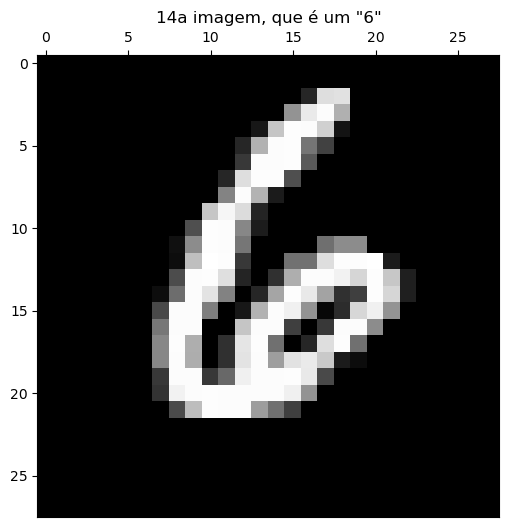

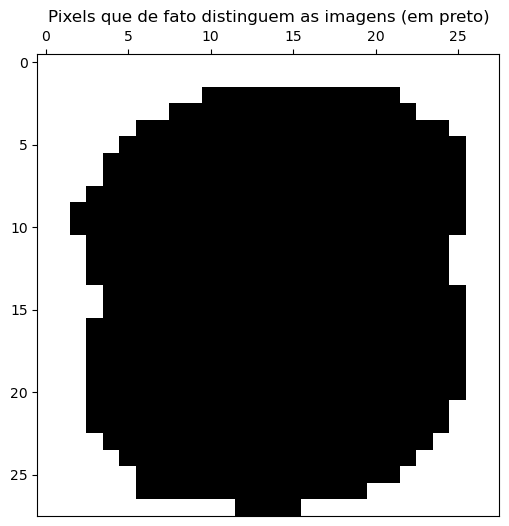



************ Iniciando com o método:  knn  ******************
Hiperparâmetro: {'n_neighbors': 3}, Acurácia: 0.964
Hiperparâmetro: {'n_neighbors': 5}, Acurácia: 0.963
Hiperparâmetro: {'n_neighbors': 7}, Acurácia: 0.961
Melhores hiperparâmetros: {'n_neighbors': 3}
Melhor acurácia (média no cross-validation): 0.964

Confusion Matrix:


array([[3425,    3,    1,    0,    0,    2,   13,    3,    1,    3],
       [   1, 3914,    6,    2,    0,    1,    1,   10,    0,    3],
       [  20,   44, 3349,   11,    4,    1,    7,   51,    6,    2],
       [   7,    6,   14, 3452,    2,   40,    4,   18,   18,   10],
       [   3,   25,    2,    0, 3271,    0,   12,   11,    1,   87],
       [  15,    8,    3,   41,    6, 3026,   34,    3,    6,   15],
       [  18,    6,    0,    0,    3,   13, 3395,    0,    3,    0],
       [   3,   39,    5,    1,   12,    2,    0, 3543,    2,   40],
       [  22,   35,   17,   66,   16,   53,   10,   10, 3150,   33],
       [   8,   12,    5,   34,   32,    3,    3,   43,    8, 3331]])

Acuracia usando amostra de teste: 0.967

Sensibilidade para cada grupo:
Grupo 0:
  Sensibilidade: 0.992
Grupo 1:
  Sensibilidade: 0.994
Grupo 2:
  Sensibilidade: 0.958
Grupo 3:
  Sensibilidade: 0.967
Grupo 4:
  Sensibilidade: 0.959
Grupo 5:
  Sensibilidade: 0.959
Grupo 6:
  Sensibilidade: 0.987
Grupo 7:
  Sensibilidade: 0.971
Grupo 8:
  Sensibilidade: 0.923
Grupo 9:
  Sensibilidade: 0.957


************ Iniciando com o método:  svmLinear  ******************
Hiperparâmetro: {'C': 0.1, 'kernel': 'linear', 'random_state': 42}, Acurácia: 0.906
Hiperparâmetro: {'C': 1, 'kernel': 'linear', 'random_state': 42}, Acurácia: 0.905
Hiperparâmetro: {'C': 10, 'kernel': 'linear', 'random_state': 42}, Acurácia: 0.905
Melhores hiperparâmetros: {'C': 0.1, 'kernel': 'linear', 'random_state': 42}
Melhor acurácia (média no cross-validation): 0.906

Confusion Matrix:


array([[3345,    0,   17,   10,    4,   29,   31,    2,    9,    4],
       [   1, 3864,   16,   18,    0,    5,    2,    7,   23,    2],
       [  39,   42, 3161,   64,   39,    4,   38,   37,   61,   10],
       [  25,   28,  105, 3156,    3,  133,    5,   22,   75,   19],
       [   8,   18,   42,    3, 3140,    7,   20,   22,    9,  143],
       [  58,   23,   39,  182,   26, 2685,   52,    4,   69,   19],
       [  27,    4,   54,    4,   28,   53, 3259,    2,    7,    0],
       [  12,   21,   48,   32,   36,    7,    0, 3385,   15,   91],
       [  46,   81,   99,  184,   18,  138,   36,   16, 2768,   26],
       [  17,   26,   17,   50,  186,   28,    1,  152,   31, 2971]])

Acuracia usando amostra de teste: 0.907

Sensibilidade para cada grupo:
Grupo 0:
  Sensibilidade: 0.969
Grupo 1:
  Sensibilidade: 0.981
Grupo 2:
  Sensibilidade: 0.904
Grupo 3:
  Sensibilidade: 0.884
Grupo 4:
  Sensibilidade: 0.920
Grupo 5:
  Sensibilidade: 0.850
Grupo 6:
  Sensibilidade: 0.948
Grupo 7:
  Sensibilidade: 0.928
Grupo 8:
  Sensibilidade: 0.811
Grupo 9:
  Sensibilidade: 0.854


************ Iniciando com o método:  svmPoly  ******************
Hiperparâmetro: {'C': 0.1, 'degree': 2, 'kernel': 'poly', 'random_state': 42}, Acurácia: 0.947
Hiperparâmetro: {'C': 0.1, 'degree': 3, 'kernel': 'poly', 'random_state': 42}, Acurácia: 0.944
Hiperparâmetro: {'C': 1, 'degree': 2, 'kernel': 'poly', 'random_state': 42}, Acurácia: 0.970
Hiperparâmetro: {'C': 1, 'degree': 3, 'kernel': 'poly', 'random_state': 42}, Acurácia: 0.969
Hiperparâmetro: {'C': 10, 'degree': 2, 'kernel': 'poly', 'random_state': 42}, Acurácia: 0.974
Hiperparâmetro: {'C': 10, 'degree': 3, 'kernel': 'poly', 'random_state

array([[3420,    0,    3,    1,    1,    6,    6,    1,    8,    5],
       [   1, 3907,    9,    1,    0,    0,    2,   10,    6,    2],
       [  13,   12, 3417,    6,    6,    0,    8,   20,   10,    3],
       [   4,    4,   31, 3458,    1,   30,    0,   14,   21,    8],
       [   4,    7,    8,    0, 3331,    1,   10,    8,    5,   38],
       [  14,    3,    8,   25,    4, 3055,   24,    0,   16,    8],
       [  14,    3,    9,    0,    7,    6, 3392,    1,    6,    0],
       [   2,   17,   21,    4,   10,    2,    0, 3559,    4,   28],
       [  16,   20,   17,   20,    5,   23,   13,    2, 3284,   12],
       [  11,   12,    3,   19,   40,    8,    0,   31,   19, 3336]])

Acuracia usando amostra de teste: 0.976

Sensibilidade para cada grupo:
Grupo 0:
  Sensibilidade: 0.991
Grupo 1:
  Sensibilidade: 0.992
Grupo 2:
  Sensibilidade: 0.978
Grupo 3:
  Sensibilidade: 0.968
Grupo 4:
  Sensibilidade: 0.976
Grupo 5:
  Sensibilidade: 0.968
Grupo 6:
  Sensibilidade: 0.987
Grupo 7:
  Sensibilidade: 0.976
Grupo 8:
  Sensibilidade: 0.962
Grupo 9:
  Sensibilidade: 0.959


************ Iniciando com o método:  svmRadial  ******************
Hiperparâmetro: {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf', 'random_state': 42}, Acurácia: 0.948
Hiperparâmetro: {'C': 0.1, 'gamma': 'auto', 'kernel': 'rbf', 'random_state': 42}, Acurácia: 0.113
Hiperparâmetro: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf', 'random_state': 42}, Acurácia: 0.973
Hiperparâmetro: {'C': 1, 'gamma': 'auto', 'kernel': 'rbf', 'random_state': 42}, Acurácia: 0.113
Hiperparâmetro: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf', 'random_state': 42}, Acurácia: 0.978
Hiperparâmetro: {'C': 10, 'gamma': 'auto', 'kernel

array([[3427,    1,    3,    1,    0,    3,    6,    1,    6,    3],
       [   1, 3911,    7,    2,    1,    1,    1,   10,    3,    1],
       [   6,    9, 3437,    5,    5,    0,    4,   18,    8,    3],
       [   1,    2,   25, 3481,    0,   20,    0,   16,   18,    8],
       [   3,    5,    6,    0, 3345,    0,    9,    8,    3,   33],
       [   7,    1,    5,   21,    6, 3073,   21,    0,   15,    8],
       [  12,    2,    4,    1,    5,    6, 3402,    0,    6,    0],
       [   2,   11,   15,    2,   13,    2,    0, 3575,    4,   23],
       [   6,    9,   15,   13,    4,   18,    9,    2, 3325,   11],
       [  10,    8,    0,   19,   26,    6,    0,   22,   11, 3377]])

Acuracia usando amostra de teste: 0.982

Sensibilidade para cada grupo:
Grupo 0:
  Sensibilidade: 0.993
Grupo 1:
  Sensibilidade: 0.993
Grupo 2:
  Sensibilidade: 0.983
Grupo 3:
  Sensibilidade: 0.975
Grupo 4:
  Sensibilidade: 0.980
Grupo 5:
  Sensibilidade: 0.973
Grupo 6:
  Sensibilidade: 0.990
Grupo 7:
  Sensibilidade: 0.980
Grupo 8:
  Sensibilidade: 0.975
Grupo 9:
  Sensibilidade: 0.971


In [1]:
# Importar as bibliotecas. 
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import numpy as np
import matplotlib.pyplot as plt

# Carregar o conjunto de dados MNIST.
mnist = fetch_openml('mnist_784', version=1)
X = mnist.data    # variáveis preditoras (pixels)
y = mnist.target  # variável alvo (rótulo do número)
print("Quantidade de imagens amostradas X quantidade de preditores (pixels):", X.shape)
print("Quantidade de rótulos:", y.shape[0], "\n")

# Exibir a imagem (28 X 28 pixels) correspondente à 14a imagem.
imagem = X.loc[14-1].values.reshape(28, 28)
plt.figure(figsize=(6, 6))
plt.gca().xaxis.tick_top()
plt.imshow(imagem, cmap='gray')
plt.title('14a imagem, que é um "6"')
plt.show()
print()

# Dividir a base de dados em conjuntos de treino (50%) e de teste (50%).
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.50, random_state=42, stratify=y)

# Remover os features correspondentes aos pixels praticamente invariantes (baixa variância).
# Exibir a imagem correspondente à máscara dos pixels de fato relevantes.
selector = VarianceThreshold(threshold=100)
selector.fit(X_treino)
m = selector.get_support().reshape(28, 28)
mascara = np.full(m.shape, 255)
mascara[m] = 0
plt.figure(figsize=(6, 6))
plt.gca().xaxis.tick_top()
plt.imshow(mascara, cmap='gray')
plt.title("Pixels que de fato distinguem as imagens (em preto)")
plt.show()

# Criar bases de dados de treino e de teste baseando-se somente na lista dos features (pixels) de fato relevantes.
featuresRelevantes = X_treino.columns[selector.get_support()].tolist()
X_treino = X_treino[featuresRelevantes]
X_teste = X_teste[featuresRelevantes]

# Usar os quatro algoritmos.
for metodo in ["knn", "svmLinear", "svmPoly", "svmRadial"]:

    # Definir a grade de hiperparâmetros e descobrir os melhores hiperparâmetros (pela acurácia).
    if metodo == "knn":
        modelo = KNeighborsClassifier()
        param_grid = {'n_neighbors': [3, 5, 7]}
        # hiperparâmetros que foram variados: número de vizinhos
    if metodo == "svmLinear":
        modelo = SVC()
        param_grid = {'C': [0.1, 1, 10], 'kernel': ['linear'], 'random_state': [42]}
        # hiperparâmetros que foram variados: C 
    if metodo == "svmPoly":
        modelo = SVC()
        param_grid = {'C': [0.1, 1, 10], 'degree': [2, 3], 'kernel': ['poly'], 'random_state': [42]} 
        # hiperparâmetros que foram variados: C e degree
    if metodo == "svmRadial":
        modelo = SVC()
        param_grid = {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'], 'kernel': ['rbf'], 'random_state': [42]} 
        # hiperparâmetros que foram variados: C (regularização) e gama
    
    print("\n\n************ Iniciando com o método: ", metodo, " ******************")
    gradeHiperparametros = GridSearchCV(modelo, param_grid, cv=4, scoring='accuracy') 
    gradeHiperparametros.fit(X_treino, y_treino)
    resultados = gradeHiperparametros.cv_results_
    for mean_score, params in zip(resultados["mean_test_score"], resultados["params"]):
        print(f"Hiperparâmetro: {params}, Acurácia: {mean_score:.3f}")
    print("Melhores hiperparâmetros:", gradeHiperparametros.best_params_)
    print(f"Melhor acurácia (média no cross-validation): {gradeHiperparametros.best_score_:.3f}")

    # Fazer as previsões usando a base de teste.
    previsoes = gradeHiperparametros.best_estimator_.predict(X_teste)
    y_teste_real = y_teste.astype(str)
    y_teste_previsto = previsoes.astype(str)

    # Imprimir a Matriz de Confusão, a Acurácia e as Sensibilidades para cada grupo.
    matriz_confusao = confusion_matrix(y_teste_real, y_teste_previsto)
    print("\nConfusion Matrix:")
    display(matriz_confusao)
    acuracia = accuracy_score(y_teste_real, y_teste_previsto)
    print(f"Acuracia usando amostra de teste: {acuracia:.3f}")
    print("\nSensibilidade para cada grupo:")
    report = classification_report(y_teste_real, y_teste_previsto, output_dict=True)
    for label  in ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']:
        sensibilidade = report[label]['recall'] # recall é o mesmo que sensibilidade
        print(f"Grupo {label}:")
        print(f"  Sensibilidade: {sensibilidade:.3f}")